In [7]:
import os
import warnings

import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import pytorch_lightning as pl
from lightning.pytorch import Trainer
import torch

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import TorchNormalizer
from pytorch_forecasting.metrics import QuantileLoss


import imageio
from matplotlib.pyplot import cm

os.chdir(os.getcwd())
warnings.filterwarnings("ignore")

In [8]:
plt.style.use(
    "https://raw.githubusercontent.com/emaldonadocruz/Publication_figure_style/master/Publication_figure_style.mplstyle"
)

In [9]:
data = pd.read_csv("../proc/test_final_kz.csv")
data["FECHA"] = pd.to_datetime(data["FECHA"] + "-5", format="%Y-%W-%w")
data.sort_values("FECHA", inplace=True)
data["time_idx"] = data.index + 1
data = data.rename(columns=lambda x: x.replace(".", "_"))
# replace spaces with underscores in column names
data.columns = data.columns.str.replace(" ", "_", regex=False)
# simple known-future calendar features (always available)
data["dow"] = data["FECHA"].dt.weekday.astype(int)
data["month"] = data["FECHA"].dt.month.astype(int)
data["group"] = "kz"
data["time_idx"] = data.groupby("group").cumcount()
data = data.drop(columns=["FECHA"])
data[data.select_dtypes(include=["int"]).columns] = data.select_dtypes(
    include=["int"]
).astype("int16")
data[data.select_dtypes(include=["float"]).columns] = data.select_dtypes(
    include=["float"]
).astype("float32")
data.head()

,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA_CGM,COSCO,EVERGREEN,HAMBURG_SUD_/_COLUMBUS_LINE,HAPAG-LLOYD,...,Close_pct_change_XSICNEFE_Index__(R2),Close_pct_change_XSICNESE_Index__(L2),Close_pct_change_XSICUENE_Index__(R1),Close_pct_change_XSICUWFE_Index__(L1),Close_pct_change_XSICNEUE_Index__(L3),Close_pct_change_BDIY_Index__(R3),time_idx,dow,month,group
0,2585,16372.0,9185.0,38606.0,5042.0,5346.0,2268.0,1700.0,7248.0,20291.0,...,-0.034848,0.030636,0.073733,-0.098472,0.031680,0.032476,0,4,1,kz
1,3162,19169.0,10410.0,47036.0,7045.0,5402.0,2828.0,2514.0,8371.0,20358.0,...,0.000785,0.020560,-0.021459,0.014124,-0.022104,-0.229358,1,4,1,kz
2,2934,17280.0,8971.0,43070.0,7255.0,4887.0,4327.0,1847.0,6337.0,16547.0,...,-0.023529,-0.067476,0.033626,-0.016713,-0.000455,-0.197846,2,4,1,kz
3,2870,14806.0,8851.0,44111.0,8654.0,4345.0,4622.0,1334.0,7098.0,14883.0,...,-0.006426,-0.017699,0.022631,0.020774,0.000455,-0.024028,3,4,1,kz
4,3080,15746.0,8817.0,47491.0,4965.0,5950.0,2608.0,2844.0,6333.0,14690.0,...,-0.076799,0.073662,0.006916,0.008326,0.035801,0.030413,4,4,2,kz


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Columns: 124 entries, RUTS_UNICOS_DIARIOS to group
dtypes: float32(117), int16(6), object(1)
memory usage: 74.9+ KB


In [11]:
v

In [12]:
cmap = plt.get_cmap("Greys")
color = cm.Greys(np.linspace(0.5, 1, 5))

Weights_pos = np.linspace(0, 0.25, 8)
Weights_neg = np.linspace(0, 1, 8)


def return_qresiduals(out):
    Quantiles_res = np.zeros([out["prediction"].shape[1], out["prediction"].shape[2]])
    for i in range(out["prediction"].shape[2]):
        Quantiles_res[:, i] = out["prediction"][0, :, i] - return_p50(
            out["prediction"][0]
        )
    return Quantiles_res


def return_quantiles(out, Weights_neg, Weights_pos, P50, Quantiles_res):
    Quantiles = np.zeros([out["prediction"].shape[1], out["prediction"].shape[2]])
    for j in range(Quantiles_res.shape[0]):
        for i in range(Quantiles_res.shape[1]):
            if Quantiles_res[j, i] < 0:
                Quantiles[j, i] = P50[j] + Weights_neg[j] * Quantiles_res[j, i]
            if Quantiles_res[j, i] == 0:
                Quantiles[j, i] = P50[j]
            if Quantiles_res[j, i] > 0:
                Quantiles[j, i] = P50[j] + Weights_pos[j] * Quantiles_res[j, i]
    return Quantiles


def return_attention(attention):
    return np.mean(attention[0, :, :].numpy(), axis=0)


def return_p50(tensor):
    return np.percentile(tensor, 50, axis=1)


def return_p10(tensor):
    return np.percentile(tensor, 10, axis=1)


def return_p90(tensor):
    return np.percentile(tensor, 90, axis=1)


def make_plot(x, out, idx):
    # all true values for y of the first sample in batch
    # idx=0

    # out = raw_predictions

    encoder_target = x["encoder_target"]
    decoder_target = x["decoder_target"]

    y_raw = out["prediction"]  # raw predictions - used for calculating loss
    y_hat = out["prediction"]
    y_quantile = out[
        "prediction"
    ]  # quantiles of shape batch_size x timesteps x n_quantiles

    y_all = torch.cat([encoder_target[0], decoder_target[0]])

    max_encoder_length = x["encoder_lengths"].max()

    y = torch.cat(
        (
            y_all[: x["encoder_lengths"][idx]],
            y_all[
                max_encoder_length : (max_encoder_length + x["decoder_lengths"][idx])
            ],
        )
    )

    y_hat = y_hat.detach().cpu()[idx, : x["decoder_lengths"][idx]]
    y_quantile = y_quantile.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    # Added
    qresiduals = return_qresiduals(out)
    y_quantile = return_quantiles(
        out, Weights_neg, Weights_pos, return_p50(y_hat), qresiduals
    )

    y_raw = y_raw.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    y = y.detach().cpu()
    n_pred = y_hat.shape[0]
    x_obs = np.arange(-(y.shape[0] - n_pred), 0)
    x_pred = np.arange(n_pred)

    fig, ax = plt.subplots()
    ax2 = ax.twinx()

    for i in range(y_quantile.shape[1] // 2):
        if len(x_pred) > 1:
            ax.fill_between(
                x_pred,
                y_quantile[:, i],
                y_quantile[:, -i - 1],
                alpha=0.45,
                color=color[i],
            )
        else:
            quantiles = torch.tensor([[y_quantile[0, i]], [y_quantile[0, -i - 1]]])
            ax.errorbar(x_pred, y[[-n_pred]], yerr=quantiles - y[-n_pred], capsize=1.0)

    lns1 = ax.plot(x_pred, return_p50(y_hat), label="Predicted", c="red")
    lns2 = ax.plot(x_obs, y[:-n_pred], label="Observed", c="black", linewidth=2)
    ax.plot(x_pred, y[-n_pred:], c="black", linewidth=2)
    # ax.plot(x_obs, y[:-n_pred], label="observed", c='black')

    lns3 = ax2.plot(
        x_obs,
        return_attention(raw_prediction["encoder_attention"][0]),
        "--",
        color="gray",
        label="Encoder attention",
    )
    ax2.set_ylabel("Attention")

    ax.set_ylabel("Rate [bbl]")
    ax.set_xlabel("Periods [days]")

    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0)


def make_plot_separate_att(x, out, idx):
    # all true values for y of the first sample in batch
    # idx=0

    # out = raw_predictions

    encoder_target = x["encoder_target"]
    decoder_target = x["decoder_target"]

    y_raw = out["prediction"]  # raw predictions - used for calculating loss
    y_hat = out["prediction"]
    y_quantile = out[
        "prediction"
    ]  # quantiles of shape batch_size x timesteps x n_quantiles

    y_all = torch.cat([encoder_target[0], decoder_target[0]])

    max_encoder_length = x["encoder_lengths"].max()

    y = torch.cat(
        (
            y_all[: x["encoder_lengths"][idx]],
            y_all[
                max_encoder_length : (max_encoder_length + x["decoder_lengths"][idx])
            ],
        )
    )

    y_hat = y_hat.detach().cpu()[idx, : x["decoder_lengths"][idx]]
    y_quantile = y_quantile.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    # Added
    qresiduals = return_qresiduals(out)
    y_quantile = return_quantiles(
        out, Weights_neg, Weights_pos, return_p50(y_hat), qresiduals
    )

    y_raw = y_raw.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    y = y.detach().cpu()
    n_pred = y_hat.shape[0]
    x_obs = np.arange(-(y.shape[0] - n_pred), 0)
    x_pred = np.arange(n_pred)

    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    # ax3 = ax.twinx()

    for i in range(y_quantile.shape[1] // 2):
        if len(x_pred) > 1:
            ax.fill_between(
                x_pred,
                y_quantile[:, i],
                y_quantile[:, -i - 1],
                alpha=0.45,
                color=color[i],
            )
        else:
            quantiles = torch.tensor([[y_quantile[0, i]], [y_quantile[0, -i - 1]]])
            ax.errorbar(x_pred, y[[-n_pred]], yerr=quantiles - y[-n_pred], capsize=1.0)

    lns1 = ax.plot(x_pred, return_p50(y_hat), label="Predicted", c="red")
    lns2 = ax.plot(x_obs, y[:-n_pred], label="Observed", c="black", linewidth=2)
    ax.plot(x_pred, y[-n_pred:], c="black", linewidth=2)
    # ax.plot(x_obs, y[:-n_pred], label="observed", c='black')

    # ax2.plot(x_obs,return_attention(raw_prediction['encoder_attention'][0]),'--',color = 'gray')
    lns3 = ax2.plot(
        x_obs,
        raw_prediction["encoder_attention"][0, 0, 0, :],
        "--",
        label="Attention head #1",
    )
    #     lns4 = ax2.plot(x_obs,
    #              raw_prediction['encoder_attention'][0, 0, 1, :],'--',
    #              label='Attention head #2')
    #     ax2.plot(x_obs,
    #              raw_prediction['encoder_attention'][0, 0, 2, :],'--',
    #              label='Attention head #3')
    #     ax2.set_ylabel('Attention')

    # ax3.plot()

    lns = lns1 + lns2 + lns3  # + lns4
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0)

    ax.set_ylabel("Rate [bbl]")
    ax.set_xlabel("Periods [days]")
    plt.show()


def make_test_plot_quantiles(x, out, idx):
    # all true values for y of the first sample in batch
    # idx=0

    # out = raw_predictions

    encoder_target = x["encoder_target"]
    decoder_target = x["decoder_target"]

    y_raw = out["prediction"]  # raw predictions - used for calculating loss
    y_hat = out["prediction"]
    y_quantile = out[
        "prediction"
    ]  # quantiles of shape batch_size x timesteps x n_quantiles

    y_all = torch.cat([encoder_target[0], decoder_target[0]])

    max_encoder_length = x["encoder_lengths"].max()

    y = torch.cat(
        (
            y_all[: x["encoder_lengths"][idx]],
            y_all[
                max_encoder_length : (max_encoder_length + x["decoder_lengths"][idx])
            ],
        )
    )

    y_hat = y_hat.detach().cpu()[idx, : x["decoder_lengths"][idx]]
    y_quantile = y_quantile.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    # Added
    qresiduals = return_qresiduals(out)
    y_quantile = return_quantiles(
        out, Weights_neg, Weights_pos, return_p50(y_hat), qresiduals
    )

    y_raw = y_raw.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    y = y.detach().cpu()
    n_pred = y_hat.shape[0]
    x_obs = np.arange(-(y.shape[0] - n_pred), 0)
    x_pred = np.arange(n_pred)

    fig, ax = plt.subplots()
    ax2 = ax.twinx()

    for i in range(y_quantile.shape[1] // 2):
        if len(x_pred) > 1:
            ax.fill_between(
                x_pred,
                y_quantile[:, i],
                y_quantile[:, -i - 1],
                alpha=0.45,
                color=color[i],
            )
        else:
            quantiles = torch.tensor([[y_quantile[0, i]], [y_quantile[0, -i - 1]]])
            ax.errorbar(x_pred, y[[-n_pred]], yerr=quantiles - y[-n_pred], capsize=1.0)

    lns1 = ax.plot(x_pred, return_p50(y_hat), label="Predicted", c="red")
    lns2 = ax.plot(x_obs, y[:-n_pred], label="Observed", c="black", linewidth=2)
    ax.plot(x_pred, y[-n_pred:], c="black", linewidth=2)
    # ax.plot(x_obs, y[:-n_pred], label="observed", c='black')

    lns3 = ax2.plot(
        x_obs,
        return_attention(raw_prediction["encoder_attention"][0]),
        "--",
        color="gray",
        label="Encoder attention",
    )
    ax2.set_ylabel("Attention")

    ax.set_ylabel("Rate [bbl]")
    ax.set_xlabel("Periods [days]")

    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0)


def make_plot_separate_att_with_events(x, out, events):
    # all true values for y of the first sample in batch
    idx = 0

    # out = raw_predictions

    encoder_target = x["encoder_target"]
    decoder_target = x["decoder_target"]

    y_raw = out["prediction"]  # raw predictions - used for calculating loss
    y_hat = out["prediction"]
    y_quantile = out[
        "prediction"
    ]  # quantiles of shape batch_size x timesteps x n_quantiles

    y_all = torch.cat([encoder_target[0], decoder_target[0]])

    max_encoder_length = x["encoder_lengths"].max()

    y = torch.cat(
        (
            y_all[: x["encoder_lengths"][idx]],
            y_all[
                max_encoder_length : (max_encoder_length + x["decoder_lengths"][idx])
            ],
        )
    )

    y_hat = y_hat.detach().cpu()[idx, : x["decoder_lengths"][idx]]
    y_quantile = y_quantile.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    # Added
    qresiduals = return_qresiduals(out)
    y_quantile = return_quantiles(
        out, Weights_neg, Weights_pos, return_p50(y_hat), qresiduals
    )

    y_raw = y_raw.detach().cpu()[idx, : x["decoder_lengths"][idx]]

    y = y.detach().cpu()
    n_pred = y_hat.shape[0]
    x_obs = np.arange(-(y.shape[0] - n_pred), 0)
    x_pred = np.arange(n_pred)

    fig, ax = plt.subplots()

    for i in range(y_quantile.shape[1] // 2):
        if len(x_pred) > 1:
            ax.fill_between(
                x_pred,
                y_quantile[:, i],
                y_quantile[:, -i - 1],
                alpha=0.45,
                color=color[i],
            )
        else:
            quantiles = torch.tensor([[y_quantile[0, i]], [y_quantile[0, -i - 1]]])
            ax.errorbar(x_pred, y[[-n_pred]], yerr=quantiles - y[-n_pred], capsize=1.0)

    lns2 = ax.plot(x_obs, y[:-n_pred], label="Observed", c="black", linewidth=2)
    ax.plot(x_pred, y[-n_pred:], c="black", linewidth=2)
    lns1 = ax.plot(x_pred, return_p50(y_hat), label="Predicted", c="red")

    ax.set_ylabel("Rate [bbl]")
    ax.set_xlabel("Periods [days]")

    ## For second axis
    ax2 = ax.twinx()

    lns3 = ax2.plot(
        x_obs,
        raw_prediction["encoder_attention"][0, 0, 0, :],
        "--",
        label="Attention head #1",
    )
    #     lns4 = ax2.plot(x_obs,
    #              raw_prediction['encoder_attention'][0, 0, 1, :],'--',
    #              label='Attention head #2')

    ax2.set_ylabel("Attention")

    ## For third axis
    ax3 = ax.twinx()
    ax3.spines.right.set_position(("axes", 1.17))  # Separation to second axis
    ax3.scatter(x_obs, events, marker="o", color="black", s=8)
    ax3.set_ylabel("Events")

    ## Legends

    lns = lns1 + lns2 + lns3  # + lns4
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0, bbox_to_anchor=(-0.12, 0.67))

    #     if savefigs==True:
    #         plt.savefig('')

    plt.show()


def return_events(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["operation"][
        time_idx_fp + 1 - max_encoder_length : time_idx_fp + 1
    ]
    return events


def return_porosity_en(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["poro"][time_idx_fp + 1 - max_encoder_length : time_idx_fp + 1]
    return events


def return_permeability_en(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["perm"][time_idx_fp + 1 - max_encoder_length : time_idx_fp + 1]
    return events


def return_events_de(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["operation"][
        time_idx_fp + 1 : time_idx_fp + 1 + max_prediction_length
    ]
    return events


def return_porosity_de(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["poro"][time_idx_fp + 1 : time_idx_fp + 1 + max_prediction_length]
    return events


def return_permeability_de(data, well_number, time_idx_fp):
    data_sub = data[data["well"] == well_number]
    events = data_sub["perm"][time_idx_fp + 1 : time_idx_fp + 1 + max_prediction_length]
    return events


def generate_gif(Name):
    file_list = []
    for file in os.listdir(weights_path):
        if file.endswith(".png"):
            # print(os.path.join(weights_path, file))
            file_list.append(file)

    with imageio.get_writer(f"{Name}.gif", mode="I") as writer:
        for filename in file_list:
            image = imageio.imread(filename)
            writer.append_data(image)

    for filename in set(file_list):
        os.remove(filename)


def create_mask(size, lengths, inverse: bool = False):
    """
    Create boolean masks of shape len(lenghts) x size.
    An entry at (i, j) is True if lengths[i] > j.
    Args:
        size (int): size of second dimension
        lengths (torch.LongTensor): tensor of lengths
        inverse (bool, optional): If true, boolean mask is inverted. Defaults to False.
    Returns:
        torch.BoolTensor: mask
    """

    if inverse:  # return where values are
        return torch.arange(size, device=lengths.device).unsqueeze(
            0
        ) < lengths.unsqueeze(-1)
    else:  # return where no values are
        return torch.arange(size, device=lengths.device).unsqueeze(
            0
        ) >= lengths.unsqueeze(-1)


def integer_histogram(data, min, max):
    uniques, counts = torch.unique(data, return_counts=True)
    if min is None:
        min = uniques.min()
    if max is None:
        max = uniques.max()
    hist = torch.zeros(max - min + 1, dtype=torch.long, device=data.device).scatter(
        dim=0, index=uniques - min, src=counts
    )
    return hist


def masked_op(tensor, op, dim, mask=None):
    if mask is None:
        mask = ~torch.isnan(tensor)
    masked = tensor.masked_fill(~mask, 0.0)
    summed = masked.sum(dim=dim)
    if op == "mean":
        return summed / mask.sum(dim=dim)  # Find the average
    elif op == "sum":
        return summed
    else:
        raise ValueError(f"unkown operation {op}")


def interpret_output(out, reduction="sum", attention_prediction_horizon=0):
    # take attention and concatenate if a list to proper attention object
    batch_size = len(out["decoder_attention"])

    ## Decoder attention

    decoder_attention = out["decoder_attention"]
    print(decoder_attention.shape)
    decoder_mask = create_mask(out["decoder_attention"].size(1), out["decoder_lengths"])
    print(decoder_mask.shape)
    decoder_attention[decoder_mask[..., None, None].expand_as(decoder_attention)] = (
        float("nan")
    )
    print(decoder_attention.shape)

    ## Encoder attention
    # roll encoder attention (so start last encoder value is on the right)
    encoder_attention = out["encoder_attention"]
    shifts = encoder_attention.size(3) - out["encoder_lengths"]
    new_index = (
        torch.arange(encoder_attention.size(3), device=encoder_attention.device)[
            None, None, None
        ].expand_as(encoder_attention)
        - shifts[:, None, None, None]
    ) % encoder_attention.size(3)
    encoder_attention = torch.gather(encoder_attention, dim=3, index=new_index)
    # expand encoder_attentiont to full size
    if encoder_attention.size(-1) < max_encoder_length:
        encoder_attention = torch.concat(
            [
                torch.full(
                    (
                        *encoder_attention.shape[:-1],
                        max_encoder_length - out["encoder_lengths"].max(),
                    ),
                    float("nan"),
                    dtype=encoder_attention.dtype,
                    device=encoder_attention.device,
                ),
                encoder_attention,
            ],
            dim=-1,
        )

        # combine attention vector
    attention = torch.concat([encoder_attention, decoder_attention], dim=-1)
    print(attention.shape)
    attention[attention < 1e-5] = float("nan")

    # histogram of decode and encode lengths
    encoder_length_histogram = integer_histogram(
        out["encoder_lengths"], min=0, max=max_encoder_length
    )
    decoder_length_histogram = integer_histogram(
        out["decoder_lengths"], min=1, max=out["decoder_variables"].size(1)
    )

    # mask where decoder and encoder where not applied when averaging variable selection weights
    encoder_variables = out["encoder_variables"].squeeze(-2)
    encode_mask = create_mask(encoder_variables.size(1), out["encoder_lengths"])
    encoder_variables = encoder_variables.masked_fill(
        encode_mask.unsqueeze(-1), 0.0
    ).sum(dim=1)
    encoder_variables /= (
        out["encoder_lengths"]
        .where(out["encoder_lengths"] > 0, torch.ones_like(out["encoder_lengths"]))
        .unsqueeze(-1)
    )

    decoder_variables = out["decoder_variables"].squeeze(-2)
    decode_mask = create_mask(decoder_variables.size(1), out["decoder_lengths"])
    decoder_variables = decoder_variables.masked_fill(
        decode_mask.unsqueeze(-1), 0.0
    ).sum(dim=1)
    decoder_variables /= out["decoder_lengths"].unsqueeze(-1)

    # static variables need no masking
    static_variables = out["static_variables"].squeeze(1)
    # attention is batch x time x heads x time_to_attend
    # average over heads + only keep prediction attention and attention on observed timesteps
    attention = masked_op(
        attention[
            :,
            attention_prediction_horizon,
            :,
            : max_encoder_length + attention_prediction_horizon,
        ],
        op="mean",
        dim=1,
    )
    print(attention.shape)

    if reduction != "none":  # if to average over batches
        static_variables = static_variables.sum(dim=0)
        encoder_variables = encoder_variables.sum(dim=0)
        decoder_variables = decoder_variables.sum(dim=0)
        attention = masked_op(attention, dim=0, op=reduction)
    else:
        attention = attention / masked_op(attention, dim=1, op="sum").unsqueeze(
            -1
        )  # renormalize
    print(attention.shape)
    interpretation = dict(
        attention=attention.masked_fill(torch.isnan(attention), 0.0),
        static_variables=static_variables,
        encoder_variables=encoder_variables,
        decoder_variables=decoder_variables,
        encoder_length_histogram=encoder_length_histogram,
        decoder_length_histogram=decoder_length_histogram,
    )

    return interpretation


def plot_interpretation(interpretation):
    figs = {}

    # attention
    fig, ax = plt.subplots()
    attention = interpretation["attention"].detach().cpu()
    attention = attention / attention.sum(-1).unsqueeze(-1)
    ax.plot(
        np.arange(-max_encoder_length, attention.size(0) - max_encoder_length),
        attention,
        color="black",
    )
    ax.set_xlabel("Time index")
    ax.set_ylabel("Attention")
    ax.set_title("Attention")
    figs["attention"] = fig

    # variable selection
    def make_selection_plot(title, values, labels):
        fig, ax = plt.subplots(figsize=(7, len(values) * 0.25 + 2))
        order = np.argsort(values)
        values = values / values.sum(-1).unsqueeze(-1)
        ax.barh(
            np.arange(len(values)),
            values[order] * 100,
            tick_label=np.asarray(labels)[order],
            color="black",
            alpha=0.85,
        )
        ax.set_title(title)
        ax.set_xlabel("Importance in %")
        plt.tight_layout()
        return fig

    figs["static_variables"] = make_selection_plot(
        "Static variables importance",
        interpretation["static_variables"].detach().cpu(),
        tft.static_variables,
    )
    figs["encoder_variables"] = make_selection_plot(
        "Encoder variables importance",
        interpretation["encoder_variables"].detach().cpu(),
        tft.encoder_variables,
    )
    figs["decoder_variables"] = make_selection_plot(
        "Decoder variables importance",
        interpretation["decoder_variables"].detach().cpu(),
        tft.decoder_variables,
    )

    return figs


def plot_attention(interpretation):
    figs = {}
    fig, ax = plt.subplots()
    attention = interpretation["attention"].detach().cpu()
    attention = attention / attention.sum(-1).unsqueeze(-1)
    ax.plot(
        np.arange(-max_encoder_length, attention.size(0) - max_encoder_length),
        attention,
        color="black",
    )
    ax.set_xlabel("Time index")
    ax.set_ylabel("Attention")
    ax.set_title("Attention")
    figs["attention"] = fig

    return figs


def make_selection_plot(title, values, labels):
    fig, ax = plt.subplots(figsize=(7, len(values) * 0.25 + 2))
    order = np.argsort(values)
    values = values / values.sum(-1).unsqueeze(-1)
    ax.barh(
        np.arange(len(values)),
        values[order] * 100,
        tick_label=np.asarray(labels)[order],
        color="black",
        alpha=0.85,
    )
    ax.set_title(title)
    ax.set_xlabel("Importance in %")
    plt.tight_layout()
    return fig


def plot_static_variable_importance(interpretation):
    figs = {}
    figs["static_variables"] = make_selection_plot(
        "Static variables importance",
        interpretation["static_variables"].detach().cpu(),
        tft.static_variables,
    )
    return figs


def plot_encoder_variables(interpretation):
    figs = {}
    figs["encoder_variables"] = make_selection_plot(
        "Encoder variables importance",
        interpretation["encoder_variables"].detach().cpu(),
        tft.encoder_variables,
    )
    return figs


def plot_decoder_variables(interpretation):
    figs = {}
    figs["decoder_variables"] = make_selection_plot(
        "Decoder variables importance",
        interpretation["decoder_variables"].detach().cpu(),
        tft.decoder_variables,
    )
    return figs

In [13]:
training_cutoff = (
    data["time_idx"].max() - 8
)  # max_prediction_length*len(data.well.unique())
training_cutoff

np.int16(148)

In [14]:
print("Missing values in group column:", data["group"].isnull().sum())
print(
    "Missing values in the filtered data:",
    data[data.time_idx <= training_cutoff]["group"].isnull().sum(),
)
filtered_data = data[data.time_idx <= training_cutoff]
print("Unique groups in filtered data:", filtered_data["group"].unique())
print("Group column dtype in filtered data:", filtered_data["group"].dtype)

Missing values in group column: 0
Missing values in the filtered data: 0
Unique groups in filtered data: ['kz']
Group column dtype in filtered data: object


In [15]:
# Check data types that might be causing issues
print("Data types of key columns:")
print(f"dow dtype: {data['dow'].dtype}, unique values: {sorted(data['dow'].unique())}")
print(
    f"month dtype: {data['month'].dtype}, unique values: {sorted(data['month'].unique())}"
)
print(f"time_idx dtype: {data['time_idx'].dtype}")
print(f"target dtype: {data[target_col].dtype}")

# Check for any other integer columns that might be inferred as categorical
int_cols = data.select_dtypes(include=["int64", "int32"]).columns.tolist()
print(f"Integer columns that might be inferred as categorical: {int_cols}")

Data types of key columns:
dow dtype: int16, unique values: [np.int16(4)]
month dtype: int16, unique values: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12)]
time_idx dtype: int16
target dtype: float32
Integer columns that might be inferred as categorical: []


In [16]:
data["group"] = 0

training = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=target_col,
    group_ids=["group"],
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length,  # ensure full window
    max_prediction_length=8,
    min_prediction_length=2,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    static_categoricals=[],  # Explicitly specify no static categoricals
    static_reals=[],  # Explicitly specify no static reals
    time_varying_known_categoricals=[],  # Explicitly specify no time-varying categoricals
    time_varying_unknown_categoricals=[],  # Explicitly specify no time-varying categoricals
    target_normalizer=TorchNormalizer(),
    allow_missing_timesteps=True,
)

In [17]:
validation = TimeSeriesDataSet.from_dataset(
    training, data, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = 32  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
)
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size * 2,
)

In [18]:
pl.seed_everything(42)

trainer = Trainer(
    max_epochs=max_epochs,
    devices=1,
    accelerator="cpu",
    enable_model_summary=True,
    enable_progress_bar=True,
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=64,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=64,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=5,
)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [19]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 15.9 K | train
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.6 M  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 51.5 K | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 16.8 K 

Epoch 4: 100%|██████████| 4/4 [00:00<00:00,  6.59it/s, v_num=8, train_loss_step=0.0122, val_loss=0.00653, train_loss_epoch=0.0125]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 4/4 [00:00<00:00,  5.77it/s, v_num=8, train_loss_step=0.0122, val_loss=0.00653, train_loss_epoch=0.0125]


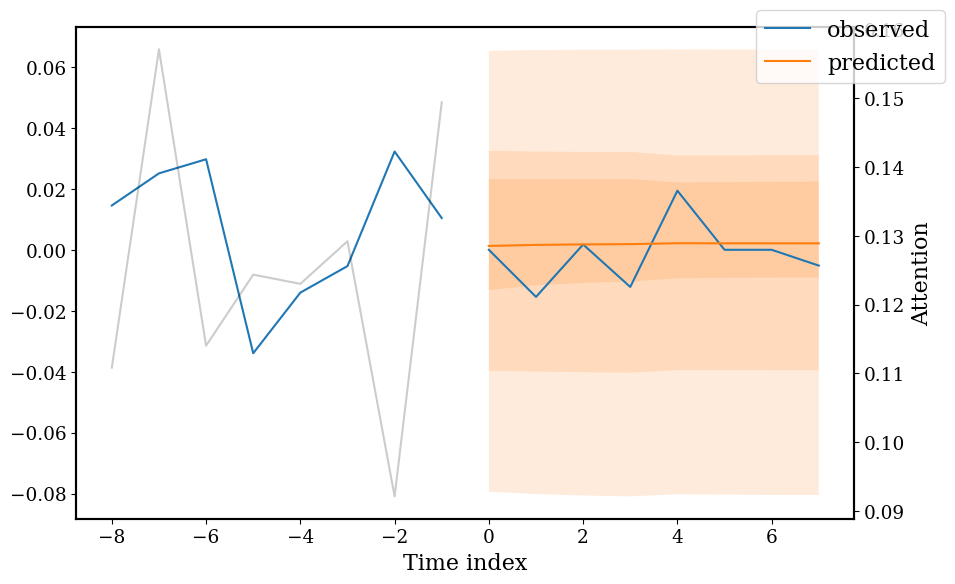

In [27]:
# Grab one batch & visualize
tft.eval()
with torch.inference_mode():
    batch = next(iter(val_dataloader))
    if isinstance(batch, (list, tuple)):
        x = batch[0]
    else:
        x = batch["x"]
    out = tft(x)
    tft.plot_prediction(x, out, idx=0)  # change idx to view different series

Output(prediction=tensor([[[-0.0794, -0.0397, -0.0132,  0.0013,  0.0232,  0.0325,  0.0653],
         [-0.0802, -0.0400, -0.0117,  0.0016,  0.0231,  0.0322,  0.0656],
         [-0.0807, -0.0402, -0.0109,  0.0018,  0.0231,  0.0322,  0.0657],
         [-0.0809, -0.0403, -0.0104,  0.0019,  0.0232,  0.0322,  0.0657],
         [-0.0803, -0.0395, -0.0093,  0.0022,  0.0221,  0.0309,  0.0658],
         [-0.0804, -0.0395, -0.0092,  0.0021,  0.0222,  0.0310,  0.0658],
         [-0.0805, -0.0395, -0.0091,  0.0021,  0.0223,  0.0310,  0.0657],
         [-0.0805, -0.0395, -0.0091,  0.0021,  0.0224,  0.0310,  0.0657]]]), encoder_attention=tensor([[[[0.0946, 0.1397, 0.1407, 0.1116, 0.1410, 0.1561, 0.0848, 0.1315],
          [0.1271, 0.1744, 0.0873, 0.1371, 0.1050, 0.1023, 0.0995, 0.1673]],

         [[0.0946, 0.1368, 0.1399, 0.1097, 0.1392, 0.1550, 0.0830, 0.1284],
          [0.1261, 0.1697, 0.0855, 0.1334, 0.1021, 0.0997, 0.0962, 0.1617]],

         [[0.0941, 0.1344, 0.1385, 0.1078, 0.1373, 0.1536, 0.